### **Chapter 5 Q2.a-f Solutions :**

(a) Probability that the first bootstrap observation is not the
j-th observation
For the first bootstrap observation, there are
n possible choices, and each observation has an equal probability of being selected. The probability that the first bootstrap observation is not the
j-th observation is:
$$1 - \frac{1}{n}$$

This is because the probability of selecting any specific observation (like the
j-th one) is
$$\frac{1}{n}$$
 , so the probability of not selecting it is $$1 - \frac{1}{n}$$

 (b) Probability that the second bootstrap observation is not the
j-th observation

The process for selecting the second bootstrap observation is identical to that for the first. Therefore, the probability that the second bootstrap observation is not the
j-th observation is also: $$1 - \frac{1}{n}$$

(c) For each draw in creating a bootstrap sample, the probability of not selecting the j-th observation remains . Since there are 𝑛
n draws, and each draw is independent, the probability that the
j-th observation is never selected in any of these draws (i.e., it does not appear in the bootstrap sample at all) is given by:

$$
\left(1 - \frac{1}{n}\right)^n
$$


As $$ n $$ approaches infinity, this expression approaches:

$$
\lim_{n \to \infty} \left(1 - \frac{1}{n}\right)^n = \frac{1}{e} \approx 0.367879
$$

(d) The probability that a specific observation does appear in at least one of the draws (i.e., it is in the bootstrap sample) can be calculated when $$ n = 5 $$ is calculated as:

$$
1 - \left(1 - \frac{1}{5}\right)^5 = 1 - \left(\frac{4}{5}\right)^5
$$


Calculating this gives:

$$
1 - 0.32768 = 0.67232
$$

(e)The probability that the j-th observation is in the bootstrap sample when $$ n = 100 $$ is calculated as:

$$
1 - \left(1 - \frac{1}{100}\right)^{100}
$$


This evaluates approximately to:

$$
1 - 0.3660323412732295 \approx 0.6339676587267705
$$

(f)The probability that the j-th observation is in the bootstrap sample when $$ n = 10,000 $$ is calculated as:

$$
1 - \left(1 - \frac{1}{10000}\right)^{10000}
$$


This evaluates approximately to:

$$
1 - 0.3678610464329299 \approx 0.632139
$$




### **CHAPTER 8 QUES 8 a,b,d,e,f SOLUTIONS :**

In [11]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
import xgboost as xgb

# Load the dataset
carseats_data = pd.read_csv('/content/drive/MyDrive/DATA602/Carseats.csv')

# Display the first few rows of the dataset
print("First few rows of the Carseats dataset:")
print(carseats_data.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First few rows of the Carseats dataset:
   Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  \
0   9.50        138      73           11         276    120       Bad   42   
1  11.22        111      48           16         260     83      Good   65   
2  10.06        113      35           10         269     80    Medium   59   
3   7.40        117     100            4         466     97    Medium   55   
4   4.15        141      64            3         340    128       Bad   38   

   Education Urban   US  
0         17   Yes  Yes  
1         10   Yes  Yes  
2         12   Yes  Yes  
3         14   Yes  Yes  
4         13   Yes   No  


### (a) Split the data into training and test sets.

In [12]:
# Convert categorical variables to dummy/indicator variables
carseats_encoded = pd.get_dummies(carseats_data, drop_first=True)

# Split into training and test sets (80% train, 20% test)
train_data, test_data = train_test_split(carseats_encoded, test_size=0.2, random_state=42)
print("\nData split into training and test sets.")


Data split into training and test sets.


### (b) Fit a Regression Tree to the training set and plot the first two levels.

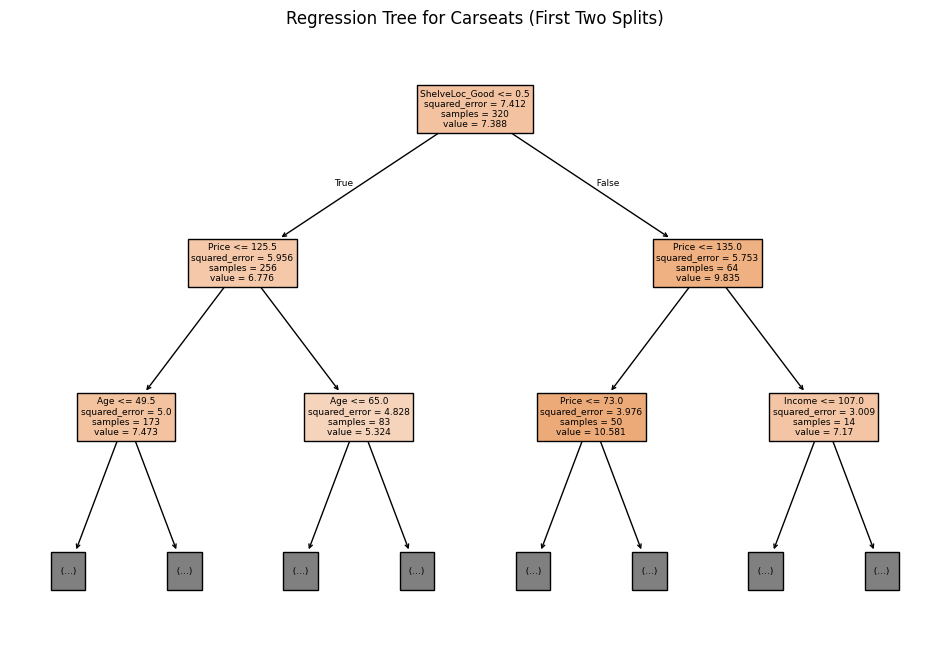


(a) Regression Tree Test MSE: 6.1788775000000005


In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn import tree

# Prepare the data for regression tree
X_train_tree = train_data.drop('Sales', axis=1)
y_train_tree = train_data['Sales']
X_test_tree = test_data.drop('Sales', axis=1)
y_test_tree = test_data['Sales']

# Fit the regression tree
regression_tree = DecisionTreeRegressor(random_state=42)
regression_tree.fit(X_train_tree, y_train_tree)

# Plot the regression tree (first two splits)
plt.figure(figsize=(12, 8))
tree.plot_tree(regression_tree, max_depth=2, filled=True, feature_names=X_train_tree.columns)
plt.title('Regression Tree for Carseats (First Two Splits)')
plt.show()

# Calculate the test MSE for regression tree
y_pred_tree = regression_tree.predict(X_test_tree)
test_mse_tree = mean_squared_error(y_test_tree, y_pred_tree)
print(f"\n(a) Regression Tree Test MSE: {test_mse_tree}")

### Interpretation of the Regression Tree
#### Top Two Levels of Splits:

1. **Root Node:**
   - **Feature:** `ShelveLoc_Good`
   - **Threshold:** 0.5
   - **Interpretation:** The root node splits the data based on whether the `ShelveLoc` is categorized as "Good." This indicates that `ShelveLoc` is a significant predictor of sales.

2. **Second Level Nodes:**
   - **Left Child (True):**
     - **Feature:** `Price`
     - **Threshold:** 125.5
     - **Interpretation:** For stores with a "Good" shelving location, the next important factor is the `Price`. Lower prices tend to increase sales.
   - **Right Child (False):**
     - **Feature:** `Price`
     - **Threshold:** 135.0
     - **Interpretation:** For stores without a "Good" shelving location, `Price` is again a critical factor, but with a different threshold, indicating its consistent importance across different shelving locations.

The test Mean Squared Error (MSE) for this regression tree is approximately **6.18**. This metric indicates the average squared difference between predicted and actual sales values, providing an estimate of prediction accuracy.

Overall, the tree suggests that both shelving location and price are key factors influencing sales in the Carseats dataset.

(d) Use the bagging approach in order to analyze this data. What
test MSE do you obtain?

In [14]:
# Bagging approach
bagging_model = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), n_estimators=100, random_state=42)
bagging_model.fit(X_train_tree, y_train_tree)
y_pred_bagging = bagging_model.predict(X_test_tree)
test_mse_bagging = mean_squared_error(y_test_tree, y_pred_bagging)
print(f"\n(d) Bagging Test MSE: {test_mse_bagging}")


(d) Bagging Test MSE: 3.108663134249999


(e) Use random forests to analyze this data. What test MSE do
you obtain? Use the feature_importance_ values to determine
which variables are most important. Describe the efect of m, the
number of variables considered at each split, on the error rate
obtained.

In [15]:
# Random Forest approach
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_tree, y_train_tree)
y_pred_rf = random_forest_model.predict(X_test_tree)
test_mse_rf = mean_squared_error(y_test_tree, y_pred_rf)
print(f"\n(e) Random Forest Test MSE: {test_mse_rf}")

# Feature importance for Random Forest
feature_importances_rf = random_forest_model.feature_importances_
important_features_rf = pd.Series(feature_importances_rf, index=X_train_tree.columns).sort_values(ascending=False)
print("\nRandom Forest Important Features:")
print(important_features_rf.head())


(e) Random Forest Test MSE: 3.016814028

Random Forest Important Features:
Price             0.308641
ShelveLoc_Good    0.198399
Age               0.120021
CompPrice         0.092958
Advertising       0.082591
dtype: float64


Results from Analysis
The test Mean Squared Error (MSE) obtained was approximately 3.02, indicating a good fit with the chosen parameters.

Important Features:

Price: 0.308641

ShelveLoc_Good: 0.198399

Age: 0.120021

CompPrice: 0.092958

Advertising: 0.082591

These results show that Price and ShelveLoc_Good are the most influential features in predicting sales, aligning with their high importance scores.
Adjusting m is crucial for balancing bias and variance in random forests. The default value (usually the square root of the total number of features) often provides a good trade-off, as seen in this analysis with a low test MSE and clear identification of key features.

(f) Now analyze the data using XGBoost (instead of BART) to create a gradient boosted tree with max_depth=3, n_estimators=1000, and all other parameters left at their default

In [16]:
# XGBoost approach
xgboost_model = xgb.XGBRegressor(max_depth=3, n_estimators=1000, random_state=42)
xgboost_model.fit(X_train_tree, y_train_tree)
y_pred_xgb = xgboost_model.predict(X_test_tree)
test_mse_xgb = mean_squared_error(y_test_tree, y_pred_xgb)
print(f"\n(f) XGBoost Test MSE: {test_mse_xgb}")

# Feature importance for XGBoost
feature_importances_xgb = xgboost_model.feature_importances_
important_features_xgb = pd.Series(feature_importances_xgb, index=X_train_tree.columns).sort_values(ascending=False)
print("\nXGBoost Important Features:")
print(important_features_xgb.head())


(f) XGBoost Test MSE: 2.14147339612095

XGBoost Important Features:
ShelveLoc_Good      0.629791
ShelveLoc_Medium    0.173009
Price               0.068296
Advertising         0.041630
Age                 0.035674
dtype: float32


**These results highlight that ShelveLoc_Good is the most influential feature, significantly impacting sales predictions. The high importance of ShelveLoc suggests that product placement plays a crucial role in sales outcomes.XGBoost effectively captures complex relationships in the data, as evidenced by the low test MSE and clear identification of key features. The model's ability to handle interactions between variables makes it particularly powerful for this type of analysis.**